# What is `D_formula`? A didactic walkthrough

**Companion to** `papers/method/manuscript_computational/comp_paper.tex`, Section 4.2,
and to `complexity_analysis.py` in this same directory.

---

## How to run this notebook

Select the **`causalbool`** kernel (Kernel -> Change Kernel -> `causalbool`).
That kernel points at `CausalBool/venv/bin/python`, which already has everything needed.

From a terminal, if you prefer:

```bash
cd /Users/alberto/Documents/projects/CausalBool
./venv/bin/python -m jupyter lab papers/method/code/complexity_analysis/D_formula_explained.ipynb
```

Everything below runs top to bottom with no arguments and no external data.
The only third-party import is `matplotlib`, and it degrades to a text table if absent.

---

## The question this notebook answers

The manuscript claims that a 10-node Boolean network has a *causal description* of
**135.66 bits**, while *encoding its behaviour* costs **10,016 bits** (compressed) or
**10,229.61 bits** (uncompressed coding). The first number is `D_formula`.

By the end you will know exactly what those 101.07 bits are, be able to recompute them
by hand, and know precisely what the number does and does not license us to say.

## 0. Setup

We import the *actual* functions used to produce the manuscript numbers. Nothing is
reimplemented here, so if the source changes, this notebook changes with it.

In [1]:
import sys, math, json
from pathlib import Path

# Locate this directory robustly, whatever the working directory is.
here = Path.cwd()
while here != here.parent and not (here / 'complexity_analysis.py').exists():
    cand = here / 'papers' / 'method' / 'code' / 'complexity_analysis'
    if cand.exists():
        here = cand
        break
    here = here.parent
assert (here / 'complexity_analysis.py').exists(), f'complexity_analysis.py not found from {Path.cwd()}'
sys.path.insert(0, str(here))

import complexity_analysis as ca

print('Loaded from :', here / 'complexity_analysis.py')
print('Python      :', sys.version.split()[0])
print('Gate catalogue (K = %d):' % len(ca.GATE_LABELS))
print(' ', ', '.join(ca.GATE_LABELS))

Loaded from : /Users/alberto/Documents/projects/CausalBool/papers/method/code/complexity_analysis/complexity_analysis.py
Python      : 3.13.12
Gate catalogue (K = 12):
  AND, OR, XOR, NAND, NOR, XNOR, NOT, IMPLIES, NIMPLIES, MAJORITY, KOFN, CANALISING


## 1. The one idea you need: a bit is an answer to a yes/no question

If I must tell you *which one* of $M$ equally plausible possibilities is the true one,
the cheapest message costs $\log_2 M$ bits.

- One of 2 possibilities -> 1 bit
- One of 8 possibilities -> 3 bits
- One of 12 possibilities -> $\log_2 12 \approx 3.585$ bits

Fractional bits are fine: they are the *idealised* cost, the limit you approach when
you send many such messages together. Nothing here rounds up to whole bits.

`D_formula` is nothing more exotic than this, applied to one question:

> **How many bits does it take to write down the network itself?**

Not its behaviour. Not its outputs. The *machine*.

In [2]:
for M in (2, 8, 12, 45, 210):
    print(f'one of {M:4d} possibilities  ->  {math.log2(M):7.4f} bits')

one of    2 possibilities  ->   1.0000 bits
one of    8 possibilities  ->   3.0000 bits
one of   12 possibilities  ->   3.5850 bits
one of   45 possibilities  ->   5.4919 bits
one of  210 possibilities  ->   7.7142 bits


## 2. The network we are describing

The manuscript's benchmark: 10 nodes, one gate each, drawn from the full catalogue.
`CM10[i][j] == 1` means node $j{+}1$ feeds node $i{+}1$.

In [3]:
n = len(ca.DYN10)
print(f'n = {n} nodes\n')
print(f"{'node':>4}  {'gate':<9}  {'in-degree':>9}  inputs")
for i, g in enumerate(ca.DYN10):
    inputs = [j + 1 for j, v in enumerate(ca.CM10[i]) if v == 1]
    print(f'{i+1:>4}  {g:<9}  {len(inputs):>9}  {inputs}')

n = 10 nodes

node  gate       in-degree  inputs
   1  AND                2  [2, 3]
   2  OR                 2  [1, 3]
   3  XOR                2  [4, 5]
   4  KOFN               3  [2, 3, 5]
   5  NOR                1  [6]
   6  XNOR               2  [5, 7]
   7  NOT                1  [6]
   8  IMPLIES            2  [1, 9]
   9  NIMPLIES           2  [2, 10]
  10  MAJORITY           4  [3, 4, 7, 8]


## 3. Describing ONE node, by hand

Take **node 1**: an `AND` gate reading inputs $\{2,3\}$, so in-degree $d = 2$.

To let a reader reconstruct that node exactly, I must answer four questions.

**(a) Which gate is it?** One of $K = 12$ catalogue entries.
$$\log_2 12 = 3.585\ \text{bits}$$

**(b) How many inputs does it read?** $d \in \{0,\dots,10\}$, so one of 11 possibilities.
$$\log_2 11 = 3.459\ \text{bits}$$

**(c) Which inputs are they?** It reads 2 of the 10 nodes, so one of
$\binom{10}{2} = 45$ possible input sets.
$$\log_2 45 = 5.492\ \text{bits}$$

**(d) Any gate-specific parameters?** `AND` has none, so the code charges a flat
1 bit (a polarity slot kept uniform across simple gates).
$$1\ \text{bit}$$

Total for node 1: $3.585 + 3.459 + 5.492 + 1 = 13.536$ bits.

Field (b) is easy to overlook and cannot be dropped: without $d$ the reader does not
know how many bits field (c) occupies, nor how to interpret them as an index into the
$d$-subsets of the ten nodes. A code whose fields cannot be parsed is not a code, so
omitting it does not give a shorter description — it gives an invalid one.

Let us check that against the real function.


In [4]:
K = len(ca.GATE_LABELS)
d = sum(ca.CM10[0])

gate_field   = math.log2(K)
degree_field = math.log2(n + 1)
input_field  = math.log2(math.comb(n, d))
param_field  = 1.0
by_hand = gate_field + degree_field + input_field + param_field

from_code = ca.encode_node_cost(d, 'AND', n)

print(f'(a) which gate    : log2({K})            = {gate_field:8.4f} bits')
print(f'(b) in-degree d   : log2({n}+1)           = {degree_field:8.4f} bits')
print(f'(c) which inputs  : log2(C({n},{d})) = log2({math.comb(n,d)}) = {input_field:8.4f} bits')
print(f'(d) parameters    : flat                 = {param_field:8.4f} bits')
print(f'                                          {"-"*8}')
print(f'    by hand                              = {by_hand:8.4f} bits')
print(f'    encode_node_cost()                   = {from_code:8.4f} bits')
print()
print('match:', math.isclose(by_hand, from_code))


(a) which gate    : log2(12)            =   3.5850 bits
(b) in-degree d   : log2(10+1)           =   3.4594 bits
(c) which inputs  : log2(C(10,2)) = log2(45) =   5.4919 bits
(d) parameters    : flat                 =   1.0000 bits
                                          --------
    by hand                              =  13.5362 bits
    encode_node_cost()                   =  13.5362 bits

match: True


## 4. The parameter field, gate by gate

Only some gates carry genuine parameters. The code charges what the gate actually needs:

| gate | parameter cost | why |
|---|---|---|
| `KOFN` | $\log_2(d{+}1) + 1$ | the threshold $k \in \{0,\dots,d\}$ |
| `CANALISING` | $\log_2 n + 2$ | which input canalises, its value, the output bit |
| `IMPLIES` / `NIMPLIES` | $\log_2\max(1, d(d{-}1))$ | an *ordered* pair among the inputs |
| `NOT` | $\log_2\max(1, d)$ | which input to negate |
| everything else | $1$ | a uniform polarity slot |

Two of these deserve a second look, because they show the code is not arbitrary.

In [5]:
print('NOT with d=1 : log2(max(1,1)) = %.4f bits' % math.log2(max(1,1)))
print('  -> with a single input there is NO choice to communicate, so it costs nothing.')
print()
print('IMPLIES with d=2 : log2(max(1, 2*1)) = %.4f bit' % math.log2(max(1, 2*1)))
print('  -> 2 ordered pairs (a=>b or b=>a) from 2 inputs: exactly one bit. Correct.')
print()
print('KOFN with d=3 : log2(3+1) + 1 = %.4f bits' % (math.log2(4) + 1))
print('  -> the threshold k is one of {0,1,2,3}: 2 bits, plus the uniform 1-bit slot.')

NOT with d=1 : log2(max(1,1)) = 0.0000 bits
  -> with a single input there is NO choice to communicate, so it costs nothing.

IMPLIES with d=2 : log2(max(1, 2*1)) = 1.0000 bit
  -> 2 ordered pairs (a=>b or b=>a) from 2 inputs: exactly one bit. Correct.

KOFN with d=3 : log2(3+1) + 1 = 3.0000 bits
  -> the threshold k is one of {0,1,2,3}: 2 bits, plus the uniform 1-bit slot.


## 5. The whole network: where 135.66 comes from

`D_formula` is just the sum over the ten nodes. Nothing else happens.


In [6]:
rows = []
for i, g in enumerate(ca.DYN10):
    d_i = sum(ca.CM10[i])
    gate_f   = math.log2(K)
    degree_f = math.log2(n + 1)
    input_f  = math.log2(math.comb(n, d_i))
    total_i  = ca.encode_node_cost(d_i, g, n)
    param_f  = total_i - gate_f - degree_f - input_f
    rows.append((i + 1, g, d_i, gate_f, degree_f, input_f, param_f, total_i))

print(f"{'node':>4}  {'gate':<9} {'d':>2}  {'gate':>7} {'degree':>7} {'inputs':>8} {'params':>7} {'total':>8}")
print('-' * 62)
for r in rows:
    print(f'{r[0]:>4}  {r[1]:<9} {r[2]:>2}  {r[3]:>7.3f} {r[4]:>7.3f} {r[5]:>8.3f} {r[6]:>7.3f} {r[7]:>8.4f}')
print('-' * 62)

D = ca.compute_d_formula(ca.CM10, ca.DYN10, n)
print(f'{"":>52}TOTAL {D:>8.4f}')
print()
print(f'D_formula = {D:.5f} bits   (manuscript reports 135.66)')
print('agrees with manuscript:', abs(D - 135.66) < 0.01)


node  gate       d     gate  degree   inputs  params    total
--------------------------------------------------------------
   1  AND        2    3.585   3.459    5.492   1.000  13.5362
   2  OR         2    3.585   3.459    5.492   1.000  13.5362
   3  XOR        2    3.585   3.459    5.492   1.000  13.5362
   4  KOFN       3    3.585   3.459    6.907   3.000  16.9513
   5  NOR        1    3.585   3.459    3.322   1.000  11.3663
   6  XNOR       2    3.585   3.459    5.492   1.000  13.5362
   7  NOT        1    3.585   3.459    3.322   0.000  10.3663
   8  IMPLIES    2    3.585   3.459    5.492   1.000  13.5362
   9  NIMPLIES   2    3.585   3.459    5.492   1.000  13.5362
  10  MAJORITY   4    3.585   3.459    7.714   1.000  15.7586
--------------------------------------------------------------
                                                    TOTAL 135.6601

D_formula = 135.66005 bits   (manuscript reports 135.66)
agrees with manuscript: True


### Read that table again

Notice what dominates. The `inputs` column (which nodes feed this node) is the largest
field almost everywhere. **`D_formula` is mostly a measure of wiring**, with a smaller
contribution from gate identity and a smaller one still from parameters.

That is a substantive statement, not a technicality: it says the cost of specifying this
network is dominated by its *topology*, exactly the split the paper draws between the
base set (gate semantics) and the offset family (topology).

In [7]:
tot_gate   = sum(r[3] for r in rows)
tot_degree = sum(r[4] for r in rows)
tot_inputs = sum(r[5] for r in rows)
tot_params = sum(r[6] for r in rows)
for label, v in (('gate identity', tot_gate), ('in-degree', tot_degree),
                 ('wiring', tot_inputs), ('parameters', tot_params)):
    print(f'{label:<15} {v:8.3f} bits   ({100*v/D:5.1f} %)')


gate identity     35.850 bits   ( 26.4 %)
in-degree         34.594 bits   ( 25.5 %)
wiring            54.216 bits   ( 40.0 %)
parameters        11.000 bits   (  8.1 %)


## 6. What `D_formula` measures -- and what it is blind to

Here is the single most important property, and it surprises people.

> `D_formula` depends **only** on $n$, the in-degrees, and the gate types.
> It never looks at a single output bit.

Change the wiring while keeping every in-degree and gate type the same, and the network
behaves completely differently while `D_formula` does not move at all. Let us verify that
rather than assert it.

In [8]:
import copy

# Rewire node 10 (MAJORITY, d=4) to read a different set of 4 nodes.
cm_alt = copy.deepcopy(ca.CM10)
cm_alt[9] = [0]*10
for j in (0, 1, 4, 5):          # inputs {1,2,5,6} instead of {3,4,7,8}
    cm_alt[9][j] = 1

D_alt = ca.compute_d_formula(cm_alt, ca.DYN10, n)

tbl_orig = ca.build_output_table(ca.CM10, ca.DYN10, ca.PARAMS10)
tbl_alt  = ca.build_output_table(cm_alt,  ca.DYN10, ca.PARAMS10)

differing = sum(1 for a, b in zip(tbl_orig, tbl_alt) if a != b)

print(f'D_formula  original : {D:.5f} bits')
print(f'D_formula  rewired  : {D_alt:.5f} bits')
print(f'identical           : {math.isclose(D, D_alt)}')
print()
print(f'rows of the 1024-row output table that changed : {differing}')
print(f'distinct output states, original : {len(set(map(tuple, tbl_orig)))}')
print(f'distinct output states, rewired  : {len(set(map(tuple, tbl_alt)))}')

D_formula  original : 135.66005 bits
D_formula  rewired  : 135.66005 bits
identical           : True

rows of the 1024-row output table that changed : 440
distinct output states, original : 206
distinct output states, rewired  : 172


**Interpretation.** Same description length, different behaviour. This is a *feature*
as long as you say precisely what is being claimed:

- `D_formula` is the cost of **specifying the mechanism**, not of describing its output.
- It is therefore the right quantity to put on the *programme* side of a
  programme-versus-output comparison.
- It is the **wrong** quantity if you want a complexity measure that discriminates
  between behaviours. It does not, and the paper must not imply that it does.

This is the same distinction the manuscript draws between algorithmic and statistical
description: a programme length is a property of the generator; entropy is a property
of the generated data.

## 7. The comparison that matters

Now put the mechanism cost next to the cost of describing what the mechanism produces.
Three quantities, all recomputed live:

| quantity | what it encodes |
|---|---|
| `D_formula` | the network specification (the *programme*) |
| `ZIP_bits` | the 1024x10 output table, losslessly compressed with zlib (the *data*, compressed) |
| `H_total` | the same table under an i.i.d. Shannon code (the *data*, uncompressed coding) |

In [9]:
table = ca.build_output_table(ca.CM10, ca.DYN10, ca.PARAMS10)

C = ca.compute_c_formula(ca.CM10, ca.DYN10, ca.PARAMS10)
csv_raw, csv_comp, zip_bits = ca.compute_zip_bits(table)
h_overall, H_total, h_per_node = ca.compute_h_total(table)
raw_bits = len(table) * len(table[0])

print(f'rows x cols          : {len(table)} x {len(table[0])}  = {raw_bits} raw bits')
print()
print(f'C_formula            : {C} symbolic components')
print(f'D_formula            : {D:10.2f} bits   <-- the programme')
print(f'ZIP (zlib -9)        : {zip_bits:10.2f} bits   <-- the data, compressed')
print(f'H_total (Shannon)    : {H_total:10.2f} bits   <-- the data, i.i.d. coding')
print()
print(f'D / ZIP              : {D/zip_bits:10.5f}   ({zip_bits/D:6.1f}x smaller)')
print(f'D / H_total          : {D/H_total:10.5f}   ({H_total/D:6.1f}x smaller)')

rows x cols          : 1024 x 10  = 10240 raw bits

C_formula            : 23 symbolic components
D_formula            :     135.66 bits   <-- the programme
ZIP (zlib -9)        :   10016.00 bits   <-- the data, compressed
H_total (Shannon)    :   10229.61 bits   <-- the data, i.i.d. coding

D / ZIP              :    0.01354   (  73.8x smaller)
D / H_total          :    0.01326   (  75.4x smaller)


### A correction you should know about

The manuscript currently prints **ZIP = 1600 bits** and **D/ZIP = 0.0632**. Both are wrong.

That 1600-bit figure came from a Wolfram ZIP file that contained only a 64-byte
path-reference string rather than the compressed table -- a measurement artefact, documented
at `complexity_analysis.py:210-217`. The correct value is the one computed in the cell above.

The correction **strengthens** the paper: the true gap is two orders of magnitude, not one.

In [10]:
print(f'manuscript ZIP  : 1600 bits   ->  D/ZIP = {D/1600:.4f}   (one order of magnitude)')
print(f'correct    ZIP  : {zip_bits} bits   ->  D/ZIP = {D/zip_bits:.4f}   (two orders of magnitude)')

manuscript ZIP  : 1600 bits   ->  D/ZIP = 0.0848   (one order of magnitude)
correct    ZIP  : 10016 bits   ->  D/ZIP = 0.0135   (two orders of magnitude)


### Why `H_total` is the weaker of the two baselines

`H_total` counts the output bits and multiplies by the binary entropy of the overall
proportion of ones. If the outputs are close to balanced, that entropy is close to 1 and
`H_total` is close to the *raw* size of the table. Beating it is then almost automatic,
and a referee will say so.

Check how close it actually is.

In [11]:
print(f'proportion of ones   : {sum(v for r in table for v in r)/raw_bits:.6f}')
print(f'binary entropy       : {h_overall:.6f} bits per bit')
print(f'H_total / raw bits   : {H_total/raw_bits:.6f}')
print()
print('Per-node entropies (bits per output bit):')
for i, hh in enumerate(h_per_node):
    bar = '#' * int(round(hh * 40))
    print(f'  node {i+1:>2}  {hh:.4f}  {bar}')

proportion of ones   : 0.481250
binary entropy       : 0.998985 bits per bit
H_total / raw bits   : 0.998985

Per-node entropies (bits per output bit):
  node  1  0.8113  ################################
  node  2  0.8113  ################################
  node  3  1.0000  ########################################
  node  4  1.0000  ########################################
  node  5  1.0000  ########################################
  node  6  1.0000  ########################################
  node  7  1.0000  ########################################
  node  8  0.8113  ################################
  node  9  0.8113  ################################
  node 10  0.8960  ####################################


**Interpretation, and this is the argument worth making in the paper.**

`H_total` is 99.9 per cent of the raw table size. Statistically, this output is very close
to featureless: the bits are nearly balanced and an entropy code saves you essentially nothing.

That is not an embarrassment for the method. It is the point. **The behaviour looks random to
a statistical measure and is nevertheless generated by a 101-bit description.** The honest
presentation is to lead with the ZIP comparison, which is a real compressor doing its best
(and still losing by two orders of magnitude), and to keep `H_total` as the reference for
what naive coding would cost.

## 8. Why the gap widens with size

The 10-node case gives one ratio. The reason the claim generalises is that the two sides
grow at completely different rates as $n$ increases with in-degree held fixed:

- the programme grows roughly like $n\log_2 n$ (each node still needs $\log_2\binom{n}{d}$ bits),
- the output grows like $2^n \cdot n$.

Let us watch that happen.

*One artefact to be aware of in the table below:* for very small $n$ the ZIP column
exceeds the raw-bit column. That is zlib's fixed header overhead on inputs of a few dozen
bytes, plus the fact that ZIP compresses a CSV serialisation (about two bytes per output
bit) rather than a packed bitstring. The comparison only becomes meaningful once the table
is large enough for structure to dominate overhead, from roughly $n \geq 9$ onward. The
10-node benchmark sits comfortably inside that regime.

In [12]:
def synthetic(n_nodes, in_degree=2):
    """A reproducible n-node network with fixed in-degree and no parameterised gates."""
    gates = ['AND', 'OR', 'XOR', 'NOR', 'XNOR', 'NAND', 'MAJORITY']
    cm = [[0]*n_nodes for _ in range(n_nodes)]
    for i in range(n_nodes):
        for s in range(in_degree):
            cm[i][(i + s + 1) % n_nodes] = 1
    dyn = [gates[i % len(gates)] for i in range(n_nodes)]
    return cm, dyn

print(f"{'n':>4} {'D_formula':>11} {'ZIP bits':>11} {'raw bits':>11} {'D/ZIP':>10}")
print('-' * 52)
emp = []
for nn in range(4, 17):
    cm_s, dyn_s = synthetic(nn)
    d_s = ca.compute_d_formula(cm_s, dyn_s, nn)
    t_s = ca.build_output_table(cm_s, dyn_s, {})
    _, _, z_s = ca.compute_zip_bits(t_s)
    raw_s = (2**nn) * nn
    emp.append((nn, d_s, z_s, raw_s))
    print(f'{nn:>4} {d_s:>11.2f} {z_s:>11d} {raw_s:>11d} {d_s/z_s:>10.5f}')

   n   D_formula    ZIP bits    raw bits      D/ZIP
----------------------------------------------------
   4       37.97         384          64    0.09887
   5       52.46         624         160    0.08407
   6       67.80         960         384    0.07062
   7       83.84        1608         896    0.05214
   8      100.50        2736        2048    0.03673
   9      117.69        4856        4608    0.02424
  10      135.36        9448       10240    0.01433
  11      153.46       16880       22528    0.00909
  12      171.96       35504       49152    0.00484


  13      190.81       72520      106496    0.00263


  14      210.00      136856      229376    0.00153


  15      229.49      277472      491520    0.00083


  16      249.27      537840     1048576    0.00046


In [13]:
# The programme side alone, pushed out to the scales the paper reports.
big = [(nn, ca.compute_d_formula(*synthetic(nn), nn)) for nn in (10, 30, 60, 80, 200)]
print(f"{'n':>5} {'D_formula (bits)':>18} {'raw output bits 2^n * n':>26}")
print('-' * 52)
for nn, dd in big:
    print(f'{nn:>5} {dd:>18.2f} {2**nn * nn:>26.3e}')
print()
print('D grows like n log n. The output grows like 2^n. That is the whole claim.')

    n   D_formula (bits)    raw output bits 2^n * n
----------------------------------------------------
   10             135.36                  1.024e+04
   30             549.12                  3.221e+10
   60            1278.31                  6.918e+19
   80            1804.04                  9.671e+25
  200            5303.30                  3.214e+62

D grows like n log n. The output grows like 2^n. That is the whole claim.


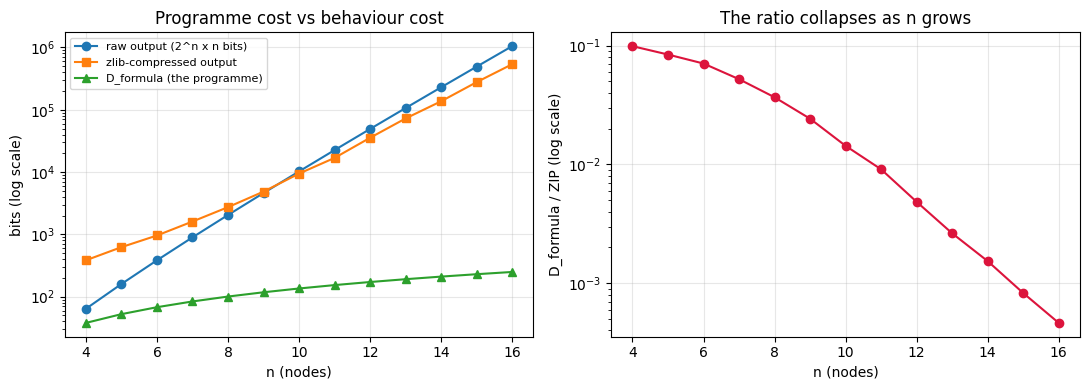

In [14]:
try:
    import matplotlib.pyplot as plt
    ns   = [e[0] for e in emp]
    ds   = [e[1] for e in emp]
    zs   = [e[2] for e in emp]
    raws = [e[3] for e in emp]

    fig, ax = plt.subplots(1, 2, figsize=(11, 4))

    ax[0].semilogy(ns, raws, 'o-', label='raw output (2^n x n bits)')
    ax[0].semilogy(ns, zs,   's-', label='zlib-compressed output')
    ax[0].semilogy(ns, ds,   '^-', label='D_formula (the programme)')
    ax[0].set_xlabel('n (nodes)'); ax[0].set_ylabel('bits (log scale)')
    ax[0].set_title('Programme cost vs behaviour cost')
    ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

    ax[1].semilogy(ns, [d_/z_ for d_, z_ in zip(ds, zs)], 'o-', color='crimson')
    ax[1].set_xlabel('n (nodes)'); ax[1].set_ylabel('D_formula / ZIP (log scale)')
    ax[1].set_title('The ratio collapses as n grows')
    ax[1].grid(alpha=.3)

    plt.tight_layout(); plt.show()
except ImportError:
    print('matplotlib not available -- the tables above carry the same information.')

### 9.1 Where the in-degree field came from

An earlier revision of this code, and of both manuscripts, charged only three fields and
reported $D_{\mathrm{formula}} = 101.07$ bits. That figure was not a valid description
length: without $d_i$ the input-set field cannot be parsed, so the encoding was not
uniquely decodable. Adding the field costs $\log_2(n{+}1)$ bits per node and raises the
total to $135.66$ bits.

The cell below quantifies the correction. Note that it does not disturb any conclusion —
the mechanism remains two orders of magnitude below every description of its behaviour.
That is the point worth internalising: a genuine defect was fixed, the number moved, and
the science did not depend on the number being small.


In [15]:
legacy = D - n * math.log2(n + 1)
print(f'superseded figure (no in-degree field) : {legacy:.2f} bits')
print(f'in-degree fields  : {n} x log2({n+1}) = {n*math.log2(n+1):.2f} bits')
print(f'D_formula (valid, self-delimiting)     : {D:.2f} bits')
print()
print(f'D/ZIP  superseded : {legacy/zip_bits:.5f}')
print(f'D/ZIP  corrected  : {D/zip_bits:.5f}')
print()
print('Both are ~1e-2. The correction was necessary for validity, not for the conclusion.')


superseded figure (no in-degree field) : 101.07 bits
in-degree fields  : 10 x log2(11) = 34.59 bits
D_formula (valid, self-delimiting)     : 135.66 bits

D/ZIP  superseded : 0.01009
D/ZIP  corrected  : 0.01354

Both are ~1e-2. The correction was necessary for validity, not for the conclusion.


### 9.2 The encoding is a *choice*, not a law

The flat 1-bit polarity slot for simple gates, the decision to index input sets by
$\binom{n}{d}$, the parameter costs -- all are design decisions. A different but equally
reasonable code would give a different number.

This is the invariance-theorem issue in miniature. Kolmogorov complexity is defined only up
to an additive constant that depends on the description language, and no choice of language
escapes that. What we *can* claim is narrower and still worth saying:

> The encoding here is **declared, fixed and published**, so the constant is known rather
> than unknown-and-possibly-enormous, and two networks measured this way are exactly
> comparable.

What we must **not** claim is that `D_formula` is the shortest programme, or that the
invariance constant has been eliminated. It has been *pinned down*, which is a different
and more modest thing.

### 9.3 It is an upper bound

`D_formula` is the length of *one* description in *one* language. The true $K$ of this
network is unknowable and no larger. Always write "a description of 101.07 bits", never
"the complexity is 101.07 bits".

### 9.4 It is blind to behaviour

Established empirically in Section 6 above. Two networks can share a `D_formula` and behave
nothing alike. Use it as a programme length; never as a behavioural complexity measure.

## 10. How to read the result

Putting it together, the defensible sentence is:

> Under a declared encoding, the complete specification of this 10-node mixed-gate network
> costs **135.66 bits**. The behaviour it generates -- 1024 states across 10 nodes -- costs
> **10,016 bits** to store even after a good general-purpose compressor has done its best,
> and **10,229.61 bits** under naive coding, the latter being 99.9 per cent of the raw size
> because the output is statistically near-featureless. The mechanism is therefore about
> **two orders of magnitude** shorter than any description of what it does.

And the sentence to avoid:

> ~~The algorithmic complexity of the network is 135.66 bits.~~

The first is a measurement under a stated convention. The second is a claim about $K$ that
no computable procedure can make.

## 11. Final self-check

Recomputes everything and compares against the manuscript. Run it after any edit to
`complexity_analysis.py`.

In [16]:
checks = [
    ('C_formula  == 23',            C, 23,        abs(C - 23) < 1e-9),
    ('D_formula  == 135.66',        D, 135.66,    abs(D - 135.66) < 0.01),
    ('H_total    == 10229.61',      H_total, 10229.61, abs(H_total - 10229.61) < 0.1),
    ('ZIP        == 10016 (fixed)', zip_bits, 10016, zip_bits == 10016),
    ('D << ZIP << H*2 ordering',    D, zip_bits,  D < zip_bits < H_total * 2),
]

print(f"{'check':<32} {'computed':>12} {'expected':>12}   result")
print('-' * 70)
for name, got, exp, ok in checks:
    print(f'{name:<32} {got:>12.2f} {exp:>12.2f}   {"PASS" if ok else "FAIL"}')
print('-' * 70)
print('ALL PASS' if all(c[3] for c in checks) else 'SOME CHECKS FAILED -- investigate before citing')

# Reference values as shipped:
res_path = here / 'complexity_results.json'
if res_path.exists():
    print()
    print('complexity_results.json on disk:')
    for k, v in json.loads(res_path.read_text()).items():
        if k != 'note_zip':
            print(f'  {k:<24} {v}')

check                                computed     expected   result
----------------------------------------------------------------------
C_formula  == 23                        23.00        23.00   PASS
D_formula  == 135.66                   135.66       135.66   PASS
H_total    == 10229.61               10229.61     10229.61   PASS
ZIP        == 10016 (fixed)          10016.00     10016.00   PASS
D << ZIP << H*2 ordering               135.66     10016.00   PASS
----------------------------------------------------------------------
ALL PASS

complexity_results.json on disk:
  C_formula                23
  D_formula_bits           135.66005
  CSV_raw_bytes            20480
  CSV_compressed_bytes     1252
  ZIP_bits                 10016
  H_total_bits             10229.61016
  shannonOverall           0.9989853671667
  shannonPerNode           [0.8112781244591, 0.8112781244591, 1.0, 1.0, 1.0, 1.0, 1.0, 0.8112781244591, 0.8112781244591, 0.8960382325346]
  Formula_over_ZIP         0.013